In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [2]:
df = pd.read_csv(
    '../data/entry_exit/MTA_Subway_Turnstile_Usage_Data__2022_20260701.csv',
    nrows=500000
)

In [3]:
df.head()

,C/A,Unit,SCP,Line Name,Division,Date,Time,Description,Entries,Exits
0,A002,R051,02-00-00,NQR456W,BMT,12/30/2022,03:00:00,REGULAR,"7,811,029","2,770,909"
1,A002,R051,02-00-00,NQR456W,BMT,12/30/2022,07:00:00,REGULAR,"7,811,032","2,770,930"
2,A002,R051,02-00-00,NQR456W,BMT,12/30/2022,11:00:00,REGULAR,"7,811,067","2,771,080"
3,A002,R051,02-00-00,NQR456W,BMT,12/30/2022,15:00:00,REGULAR,"7,811,217","2,771,126"
4,A002,R051,02-00-00,NQR456W,BMT,12/30/2022,19:00:00,REGULAR,"7,811,477","2,771,174"


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 10 columns):
 #   Column                                                      Non-Null Count   Dtype
---  ------                                                      --------------   -----
 0   C/A                                                         500000 non-null  str  
 1   Unit                                                        500000 non-null  str  
 2   SCP                                                         500000 non-null  str  
 3   Line Name                                                   500000 non-null  str  
 4   Division                                                    500000 non-null  str  
 5   Date                                                        500000 non-null  str  
 6   Time                                                        500000 non-null  str  
 7   Description                                                 500000 non-null  str  
 8   Entries        

In [5]:
df.columns = df.columns.str.strip().str.replace('"', '')

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(10)

Shape: (500000, 10)
Columns: ['C/A', 'Unit', 'SCP', 'Line Name', 'Division', 'Date', 'Time', 'Description', 'Entries', 'Exits']


,C/A,Unit,SCP,Line Name,Division,Date,Time,Description,Entries,Exits
0,A002,R051,02-00-00,NQR456W,BMT,12/30/2022,03:00:00,REGULAR,"7,811,029","2,770,909"
1,A002,R051,02-00-00,NQR456W,BMT,12/30/2022,07:00:00,REGULAR,"7,811,032","2,770,930"
2,A002,R051,02-00-00,NQR456W,BMT,12/30/2022,11:00:00,REGULAR,"7,811,067","2,771,080"
3,A002,R051,02-00-00,NQR456W,BMT,12/30/2022,15:00:00,REGULAR,"7,811,217","2,771,126"
4,A002,R051,02-00-00,NQR456W,BMT,12/30/2022,19:00:00,REGULAR,"7,811,477","2,771,174"
5,A002,R051,02-00-00,NQR456W,BMT,12/30/2022,23:00:00,REGULAR,"7,811,576","2,771,206"
6,A002,R051,02-00-01,NQR456W,BMT,12/30/2022,03:00:00,REGULAR,"6,907,603","1,632,919"
7,A002,R051,02-00-01,NQR456W,BMT,12/30/2022,07:00:00,REGULAR,"6,907,607","1,632,933"
8,A002,R051,02-00-01,NQR456W,BMT,12/30/2022,11:00:00,REGULAR,"6,907,630","1,633,000"
9,A002,R051,02-00-01,NQR456W,BMT,12/30/2022,15:00:00,REGULAR,"6,907,758","1,633,046"


In [6]:
# Remove quotes and commas from Entries/Exits, convert to numeric
for col in ['Entries', 'Exits']:
    df[col] = df[col].astype(str).str.replace('"', '').str.replace(',', '')
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [7]:
# Parse Date and Time into a single datetime column
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='mixed')
df['Date'] = pd.to_datetime(df['Date'], format='mixed')

# Create a unique turnstile identifier
df['Turnstile_ID'] = df['C/A'] + '_' + df['Unit'] + '_' + df['SCP']

print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Unique turnstiles: {df['Turnstile_ID'].nunique()}")
print(f"Unique stations (C/A): {df['C/A'].nunique()}")
df.head()


Date range: 2022-12-14 00:00:00 to 2022-12-30 00:00:00
Unique turnstiles: 5033
Unique stations (C/A): 752


,C/A,Unit,SCP,Line Name,Division,Date,Time,Description,Entries,Exits,DateTime,Turnstile_ID
0,A002,R051,02-00-00,NQR456W,BMT,2022-12-30,03:00:00,REGULAR,7811029,2770909,2022-12-30 03:00:00,A002_R051_02-00-00
1,A002,R051,02-00-00,NQR456W,BMT,2022-12-30,07:00:00,REGULAR,7811032,2770930,2022-12-30 07:00:00,A002_R051_02-00-00
2,A002,R051,02-00-00,NQR456W,BMT,2022-12-30,11:00:00,REGULAR,7811067,2771080,2022-12-30 11:00:00,A002_R051_02-00-00
3,A002,R051,02-00-00,NQR456W,BMT,2022-12-30,15:00:00,REGULAR,7811217,2771126,2022-12-30 15:00:00,A002_R051_02-00-00
4,A002,R051,02-00-00,NQR456W,BMT,2022-12-30,19:00:00,REGULAR,7811477,2771174,2022-12-30 19:00:00,A002_R051_02-00-00


In [8]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().mean() * 100).round(2)
}).sort_values('Missing %', ascending=False)

print(missing[missing['Missing Count'] > 0])

if missing['Missing Count'].sum() == 0:
    print("No missing values found!")


Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
No missing values found!


In [9]:
# Sort by turnstile and datetime
df = df.sort_values(['Turnstile_ID', 'DateTime']).reset_index(drop=True)

# Compute difference within each turnstile group
df['Net_Entries'] = df.groupby('Turnstile_ID')['Entries'].diff()
df['Net_Exits'] = df.groupby('Turnstile_ID')['Exits'].diff()

# Remove negative values and unreasonably large values (counter resets)
# A single turnstile can't have more than ~10,000 swipes in 4 hours
UPPER_LIMIT = 10000

df.loc[df['Net_Entries'] < 0, 'Net_Entries'] = np.nan
df.loc[df['Net_Entries'] > UPPER_LIMIT, 'Net_Entries'] = np.nan
df.loc[df['Net_Exits'] < 0, 'Net_Exits'] = np.nan
df.loc[df['Net_Exits'] > UPPER_LIMIT, 'Net_Exits'] = np.nan

print(f"After cleaning - valid Net_Entries: {df['Net_Entries'].notna().sum():,}")
print(f"After cleaning - valid Net_Exits: {df['Net_Exits'].notna().sum():,}")
print(f"\nNet Entries stats:")
print(df['Net_Entries'].describe())
print(f"\nNet Exits stats:")
print(df['Net_Exits'].describe())


After cleaning - valid Net_Entries: 490,278
After cleaning - valid Net_Exits: 492,194

Net Entries stats:
count    490278.000000
mean         62.304678
std          94.031387
min           0.000000
25%           4.000000
50%          25.000000
75%          83.000000
max        5121.000000
Name: Net_Entries, dtype: float64

Net Exits stats:
count    492194.000000
mean         95.528345
std         157.889594
min           0.000000
25%           8.000000
50%          38.000000
75%         115.000000
max        7571.000000
Name: Net_Exits, dtype: float64


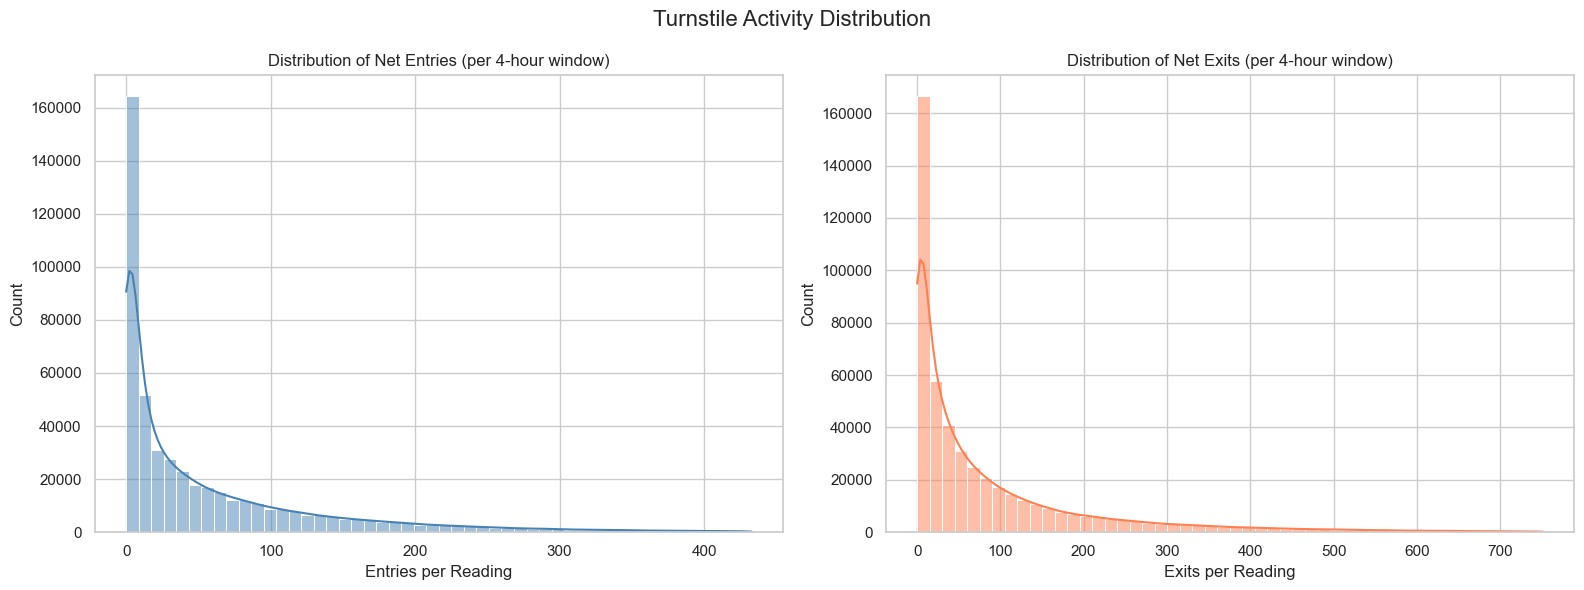

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Net Entries distribution (cap at 99th percentile for visibility)
cap_entries = df['Net_Entries'].quantile(0.99)
sns.histplot(df[df['Net_Entries'] <= cap_entries]['Net_Entries'].dropna(),
             kde=True, ax=axes[0], color='steelblue', bins=50)
axes[0].set_title('Distribution of Net Entries (per 4-hour window)')
axes[0].set_xlabel('Entries per Reading')

# Net Exits distribution
cap_exits = df['Net_Exits'].quantile(0.99)
sns.histplot(df[df['Net_Exits'] <= cap_exits]['Net_Exits'].dropna(),
             kde=True, ax=axes[1], color='coral', bins=50)
axes[1].set_title('Distribution of Net Exits (per 4-hour window)')
axes[1].set_xlabel('Exits per Reading')

plt.suptitle('Turnstile Activity Distribution', fontsize=16)
plt.tight_layout()
plt.show()

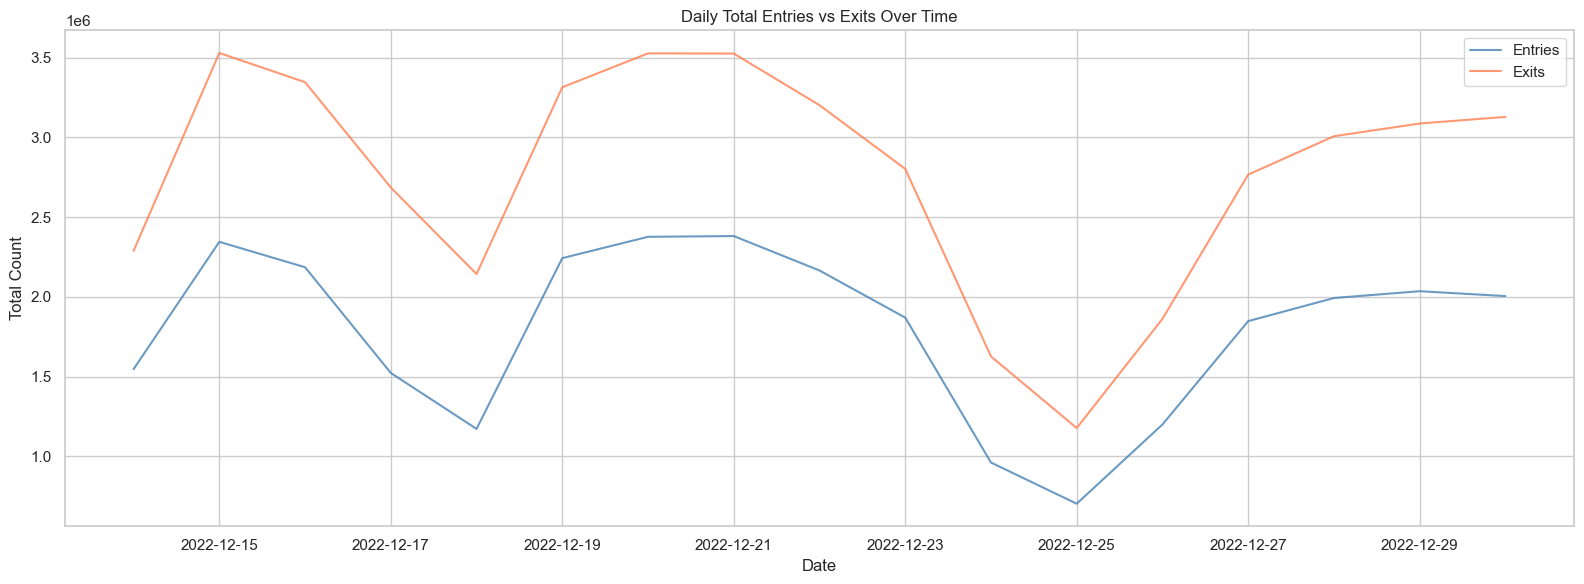

In [11]:
daily = df.groupby(df['Date'].dt.date).agg(
    Total_Entries=('Net_Entries', 'sum'),
    Total_Exits=('Net_Exits', 'sum')
).dropna()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(daily.index, daily['Total_Entries'], label='Entries', color='steelblue', alpha=0.8)
ax.plot(daily.index, daily['Total_Exits'], label='Exits', color='coral', alpha=0.8)
ax.set_title('Daily Total Entries vs Exits Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Total Count')
ax.legend()
plt.tight_layout()
plt.show()

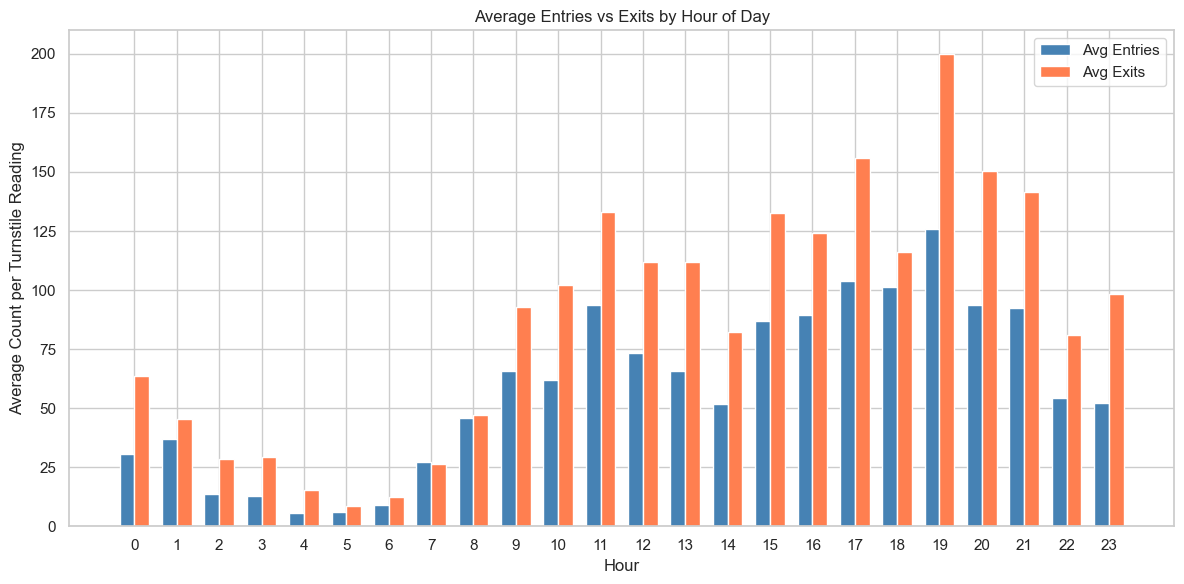

In [12]:
df['Hour'] = df['DateTime'].dt.hour

hourly = df.groupby('Hour').agg(
    Avg_Entries=('Net_Entries', 'mean'),
    Avg_Exits=('Net_Exits', 'mean')
).dropna()

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(hourly))
width = 0.35
ax.bar(x - width/2, hourly['Avg_Entries'], width, label='Avg Entries', color='steelblue')
ax.bar(x + width/2, hourly['Avg_Exits'], width, label='Avg Exits', color='coral')
ax.set_title('Average Entries vs Exits by Hour of Day')
ax.set_xlabel('Hour')
ax.set_ylabel('Average Count per Turnstile Reading')
ax.set_xticks(x)
ax.set_xticklabels(hourly.index)
ax.legend()
plt.tight_layout()
plt.show()

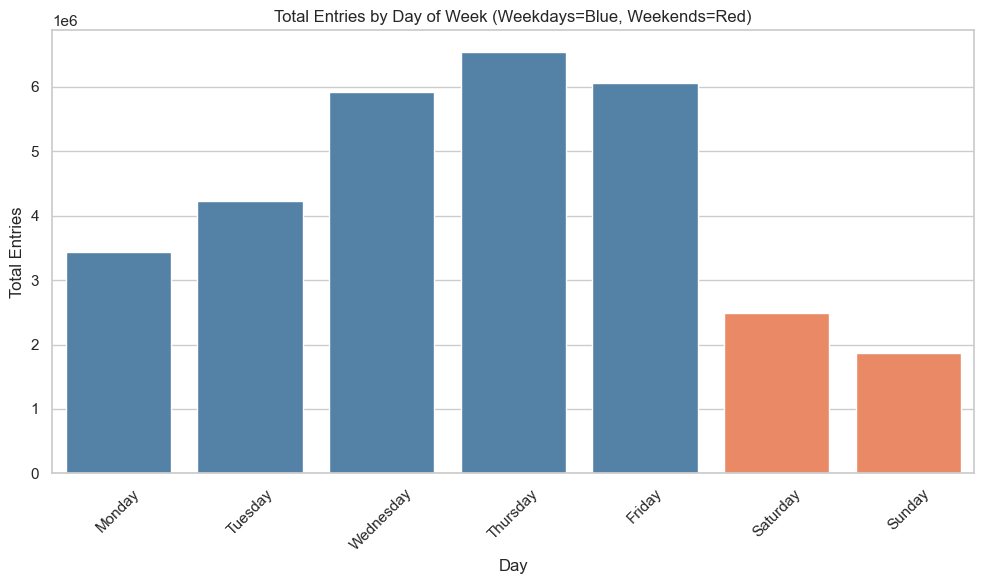

In [13]:
df['DayOfWeek'] = df['DateTime'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

dow = df.groupby('DayOfWeek')['Net_Entries'].sum().reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue']*5 + ['coral']*2  # Weekday vs Weekend
sns.barplot(x=dow.index, y=dow.values, ax=ax, palette=colors)
ax.set_title('Total Entries by Day of Week (Weekdays=Blue, Weekends=Red)')
ax.set_xlabel('Day')
ax.set_ylabel('Total Entries')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()


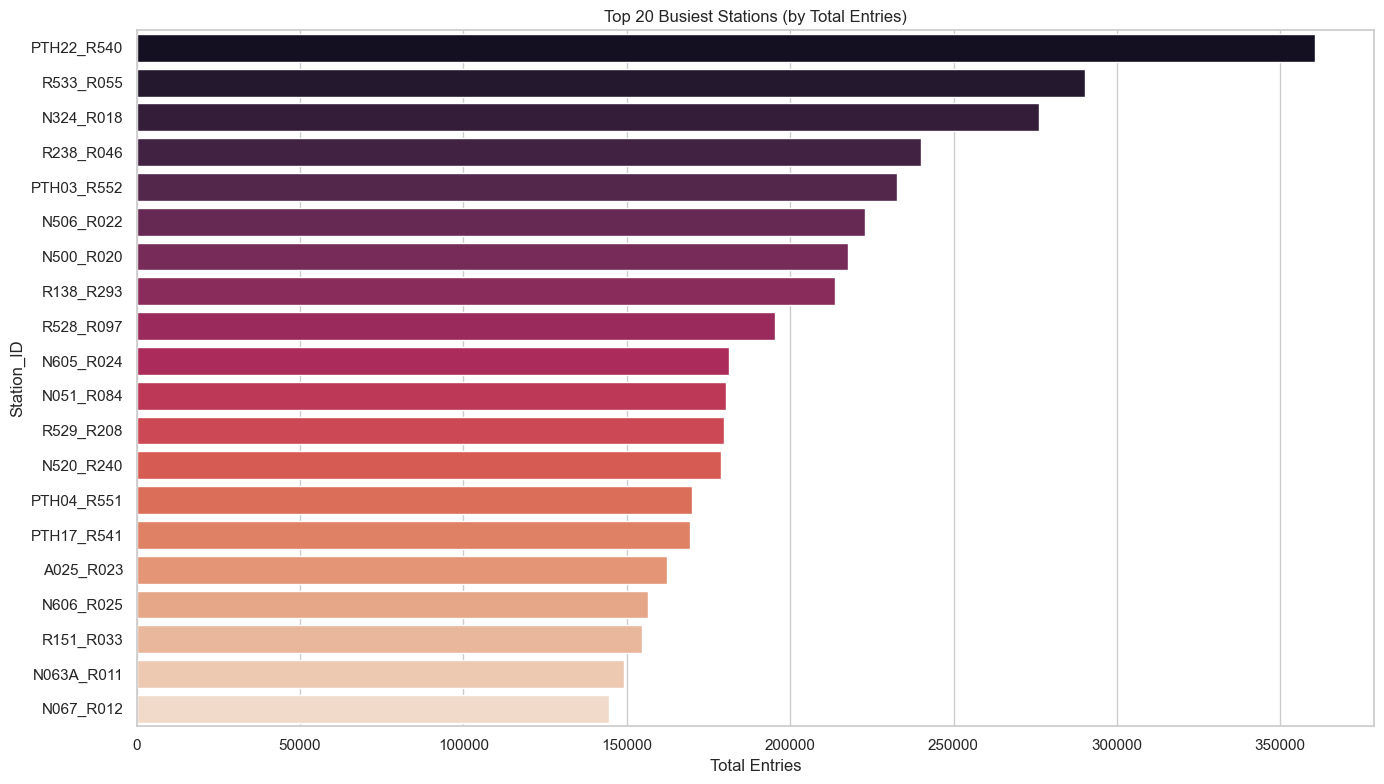

In [14]:
# C/A + Unit typically represents a station
df['Station_ID'] = df['C/A'] + '_' + df['Unit']
station_traffic = df.groupby('Station_ID')['Net_Entries'].sum().nlargest(20)

fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(x=station_traffic.values, y=station_traffic.index, ax=ax, palette='rocket')
ax.set_title('Top 20 Busiest Stations (by Total Entries)')
ax.set_xlabel('Total Entries')
plt.tight_layout()
plt.show()

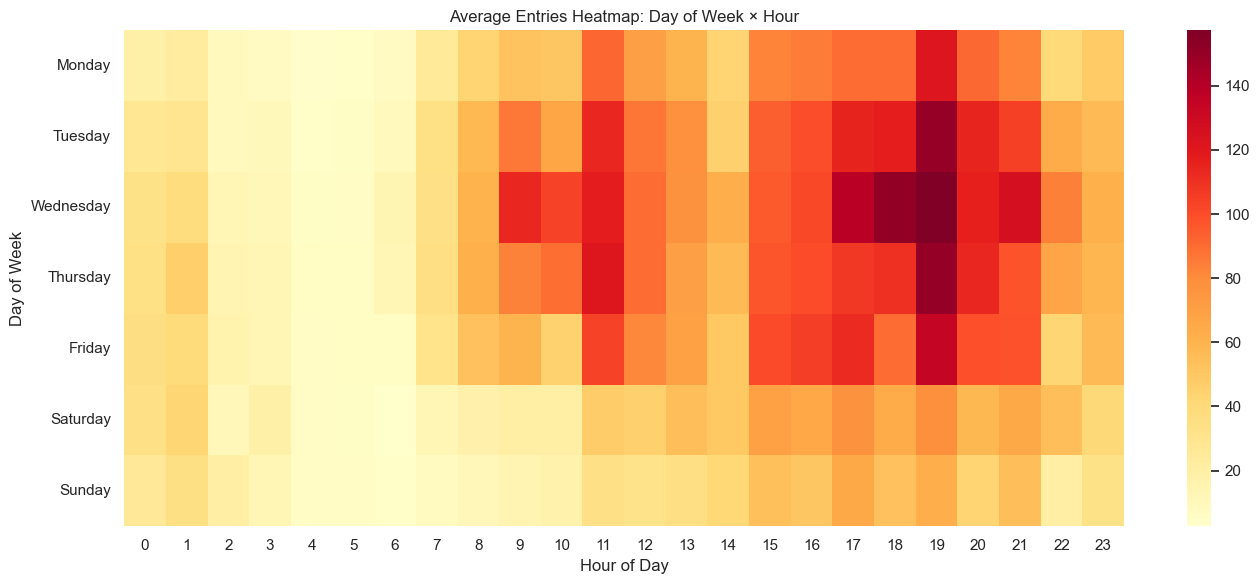

In [15]:
heatmap_data = df.groupby(['DayOfWeek', 'Hour'])['Net_Entries'].mean().unstack()
heatmap_data = heatmap_data.reindex(day_order)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, fmt='.0f', ax=ax)
ax.set_title('Average Entries Heatmap: Day of Week × Hour')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.show()


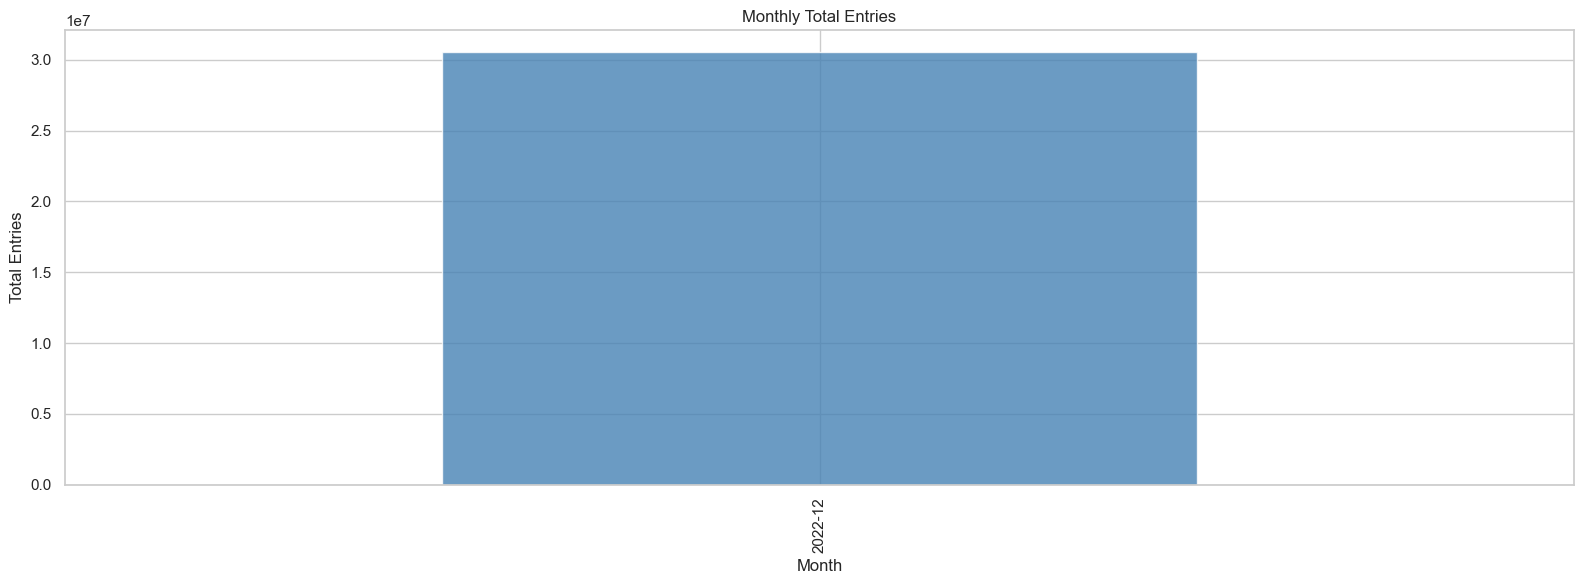

In [16]:
df['YearMonth'] = df['DateTime'].dt.to_period('M')
monthly = df.groupby('YearMonth')['Net_Entries'].sum()

fig, ax = plt.subplots(figsize=(16, 6))
monthly.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Monthly Total Entries')
ax.set_xlabel('Month')
ax.set_ylabel('Total Entries')
# Show every nth label to avoid crowding
n = max(1, len(monthly) // 12)
for i, label in enumerate(ax.get_xticklabels()):
    if i % n != 0:
        label.set_visible(False)
plt.tight_layout()
plt.show()

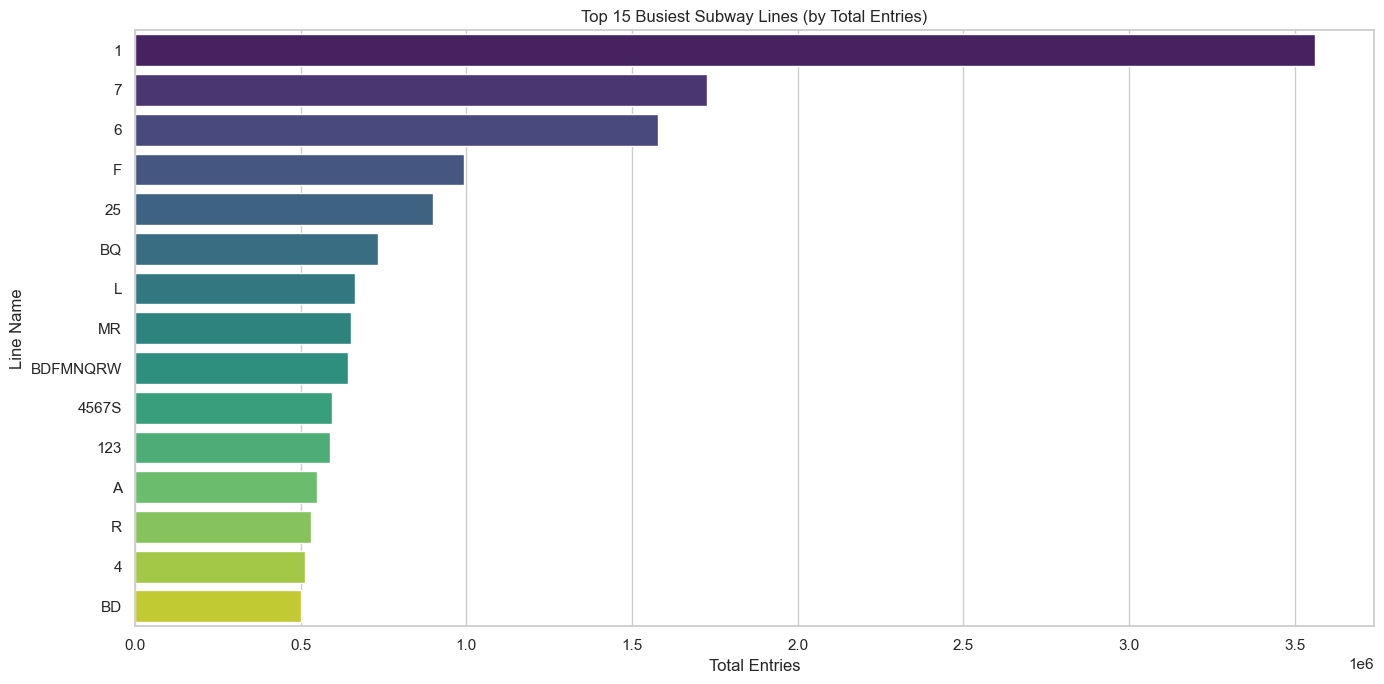

In [17]:
line_traffic = df.groupby('Line Name')['Net_Entries'].sum().nlargest(15)

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(x=line_traffic.values, y=line_traffic.index, ax=ax, palette='viridis')
ax.set_title('Top 15 Busiest Subway Lines (by Total Entries)')
ax.set_xlabel('Total Entries')
plt.tight_layout()
plt.show()

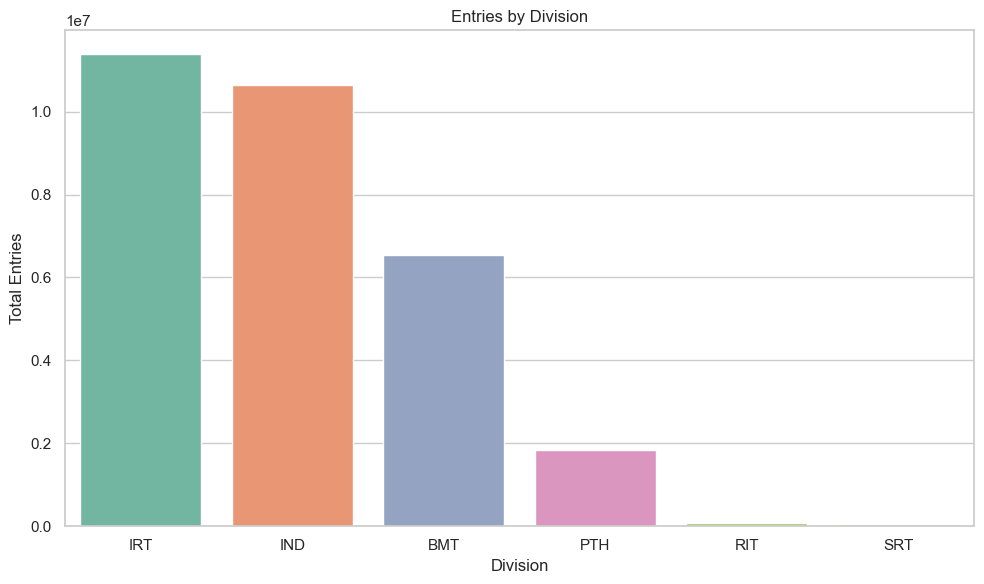

In [18]:
div_traffic = df.groupby('Division')['Net_Entries'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=div_traffic.index, y=div_traffic.values, ax=ax, palette='Set2')
ax.set_title('Entries by Division')
ax.set_xlabel('Division')
ax.set_ylabel('Total Entries')
plt.tight_layout()
plt.show()

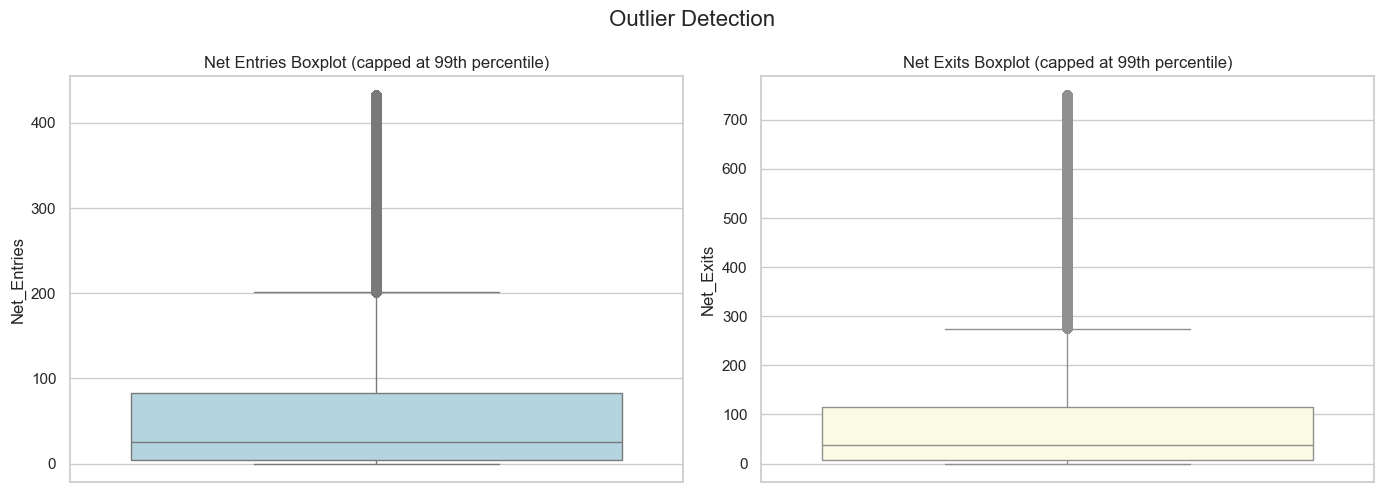

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df['Net_Entries'].dropna().clip(upper=df['Net_Entries'].quantile(0.99)),
            ax=axes[0], color='lightblue')
axes[0].set_title('Net Entries Boxplot (capped at 99th percentile)')

sns.boxplot(y=df['Net_Exits'].dropna().clip(upper=df['Net_Exits'].quantile(0.99)),
            ax=axes[1], color='lightyellow')
axes[1].set_title('Net Exits Boxplot (capped at 99th percentile)')

plt.suptitle('Outlier Detection', fontsize=16)
plt.tight_layout()
plt.show()

In [20]:
print("=" * 60)
print("EDA SUMMARY — MTA Subway Turnstile Data")
print("=" * 60)
print(f"Total Records       : {len(df):,}")
print(f"Date Range          : {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Unique Turnstiles   : {df['Turnstile_ID'].nunique():,}")
print(f"Unique Stations     : {df['Station_ID'].nunique():,}")
print(f"Unique Lines        : {df['Line Name'].nunique()}")
print(f"Avg Entries/Reading : {df['Net_Entries'].mean():.1f}")
print(f"Avg Exits/Reading   : {df['Net_Exits'].mean():.1f}")
print(f"Missing Values      : {df[['Net_Entries','Net_Exits']].isnull().sum().sum():,}")
print(f"Memory Usage        : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print("=" * 60)

EDA SUMMARY — MTA Subway Turnstile Data
Total Records       : 500,000
Date Range          : 2022-12-14 to 2022-12-30
Unique Turnstiles   : 5,033
Unique Stations     : 752
Unique Lines        : 114
Avg Entries/Reading : 62.3
Avg Exits/Reading   : 95.5
Missing Values      : 17,528
Memory Usage        : 296.3 MB
